In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q seaborn

In [ ]:
import pandas as pd
from datasets import load_dataset
from IPython.display import display

squad = load_dataset('rajpurkar/squad')      # SQuAD v1.1
mmlu  = load_dataset('cais/mmlu', 'all')      # MMLU, all subjects

print('SQuAD splits and row counts:')
for k, v in squad.items():
    print(f'  {k:18s} rows={v.num_rows:>6}  columns={v.column_names}')

print('\nMMLU splits and row counts:')
for k, v in mmlu.items():
    print(f'  {k:18s} rows={v.num_rows:>6}  columns={v.column_names}')

README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 14.5MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 1.82MB            

plain_text/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/14042 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1531 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/285 [00:00<?, ? examples/s]

Generating auxiliary_train split:   0%|          | 0/99842 [00:00<?, ? examples/s]

SQuAD splits and row counts:
  train              rows= 87599  columns=['id', 'title', 'context', 'question', 'answers']
  validation         rows= 10570  columns=['id', 'title', 'context', 'question', 'answers']

MMLU splits and row counts:
  test               rows= 14042  columns=['question', 'subject', 'choices', 'answer']
  validation         rows=  1531  columns=['question', 'subject', 'choices', 'answer']
  dev                rows=   285  columns=['question', 'subject', 'choices', 'answer']
  auxiliary_train    rows= 99842  columns=['question', 'subject', 'choices', 'answer']


In [ ]:
mmlu_df = mmlu['test'].to_pandas()

print('SHAPE (rows, columns):', mmlu_df.shape)
print('ROW COUNT:', len(mmlu_df))
print('UNIQUE SUBJECTS (all 57):', mmlu_df['subject'].nunique())

print('\nHEAD:')
display(mmlu_df.head())

print('\nINFO:')
mmlu_df.info()

print('\nNULL VALUES per column:')
print(mmlu_df.isnull().sum())

print('\nCorrect-answer distribution (0=A,1=B,2=C,3=D):')
print(mmlu_df['answer'].value_counts().sort_index())

SHAPE (rows, columns): (14042, 4)
ROW COUNT: 14042
UNIQUE SUBJECTS (all 57): 57

HEAD:


,question,subject,choices,answer
0,Find the degree for the given field extension ...,abstract_algebra,"[0, 4, 2, 6]",1
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,"[8, 2, 24, 120]",2
2,Find all zeros in the indicated finite field o...,abstract_algebra,"[0, 1, 0,1, 0,4]",3
3,Statement 1 | A factor group of a non-Abelian ...,abstract_algebra,"[True, True, False, False, True, False, False,...",1
4,Find the product of the given polynomials in t...,abstract_algebra,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1



INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14042 entries, 0 to 14041
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  14042 non-null  object
 1   subject   14042 non-null  object
 2   choices   14042 non-null  object
 3   answer    14042 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 438.9+ KB

NULL VALUES per column:
question    0
subject     0
choices     0
answer      0
dtype: int64

Correct-answer distribution (0=A,1=B,2=C,3=D):
answer
0    3222
1    3462
2    3582
3    3776
Name: count, dtype: int64


In [ ]:
squad_df = squad['validation'].to_pandas()

print('SHAPE (rows, columns):', squad_df.shape)
print('ROW COUNT:', len(squad_df))
print('UNIQUE ARTICLES (titles):', squad_df['title'].nunique())
print('\nHEAD:')
display(squad_df.head())
print('\nINFO:')
squad_df.info()
print('\nNULL VALUES per column:')
print(squad_df.isnull().sum())
has_ans = squad_df['answers'].apply(lambda a: len(a['text']) > 0)
print('\nrows with at least one answer:', int(has_ans.sum()), '/', len(squad_df))

SHAPE (rows, columns): (10570, 5)
ROW COUNT: 10570
UNIQUE ARTICLES (titles): 48

HEAD:


,id,title,context,question,answers
0,56be4db0acb8001400a502ec,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team represented the AFC at Super Bo...,"{'text': ['Denver Broncos', 'Denver Broncos', ..."
1,56be4db0acb8001400a502ed,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team represented the NFC at Super Bo...,"{'text': ['Carolina Panthers', 'Carolina Panth..."
2,56be4db0acb8001400a502ee,Super_Bowl_50,Super Bowl 50 was an American football game to...,Where did Super Bowl 50 take place?,"{'text': ['Santa Clara, California', 'Levi's S..."
3,56be4db0acb8001400a502ef,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team won Super Bowl 50?,"{'text': ['Denver Broncos', 'Denver Broncos', ..."
4,56be4db0acb8001400a502f0,Super_Bowl_50,Super Bowl 50 was an American football game to...,What color was used to emphasize the 50th anni...,"{'text': ['gold', 'gold', 'gold'], 'answer_sta..."



INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10570 entries, 0 to 10569
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        10570 non-null  object
 1   title     10570 non-null  object
 2   context   10570 non-null  object
 3   question  10570 non-null  object
 4   answers   10570 non-null  object
dtypes: object(5)
memory usage: 413.0+ KB

NULL VALUES per column:
id          0
title       0
context     0
question    0
answers     0
dtype: int64

rows with at least one answer: 10570 / 10570


In [ ]:
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

sns.set_theme(style='whitegrid', palette='deep', context='paper', font_scale=1.35)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300          # print quality
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'

PROJECT_ROOT = '/content/drive/MyDrive/thesis_rag'
FIG_DIR = f'{PROJECT_ROOT}/results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

SQUAD_C = '#2c6fbb'   # blue for SQuAD throughout
MMLU_C  = '#e08a1e'   # orange for MMLU throughout

def save_fig(name):
    plt.savefig(f'{FIG_DIR}/{name}.png')
    plt.show()
    print('saved:', f'{FIG_DIR}/{name}.png')


In [ ]:
tok = AutoTokenizer.from_pretrained('BAAI/bge-base-en-v1.5')
def ntok(text): return len(tok.encode(text, add_special_tokens=False))

def load(rel): return json.load(open(f'{PROJECT_ROOT}/{rel}'))

squad_corpus = load('data/squad/corpus.json')
mmlu_corpus  = load('data/mmlu/corpus.json')
squad_eval   = load('data/squad/squad_eval.json')
mmlu_eval    = load('data/mmlu/mmlu_eval.json')

# token-length arrays
sq_q_len   = np.array([ntok(q['question']) for q in squad_eval])
sq_ctx_len = np.array([ntok(d['text']) for d in squad_corpus])
sq_ans_len = np.array([ntok(q['answers'][0]) for q in squad_eval])

mm_q_len   = np.array([ntok(q['question']) for q in mmlu_eval])
mm_art_len = np.array([ntok(d['text']) for d in mmlu_corpus])
mm_ans_len = np.array([ntok(q['answer_text']) for q in mmlu_eval])

print('SQuAD: %d questions, %d contexts | MMLU: %d questions, %d articles'
      % (len(sq_q_len), len(sq_ctx_len), len(mm_q_len), len(mm_art_len)))


config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (617 > 512). Running this sequence through the model will result in indexing errors


SQuAD: 500 questions, 2067 contexts | MMLU: 500 questions, 546 articles


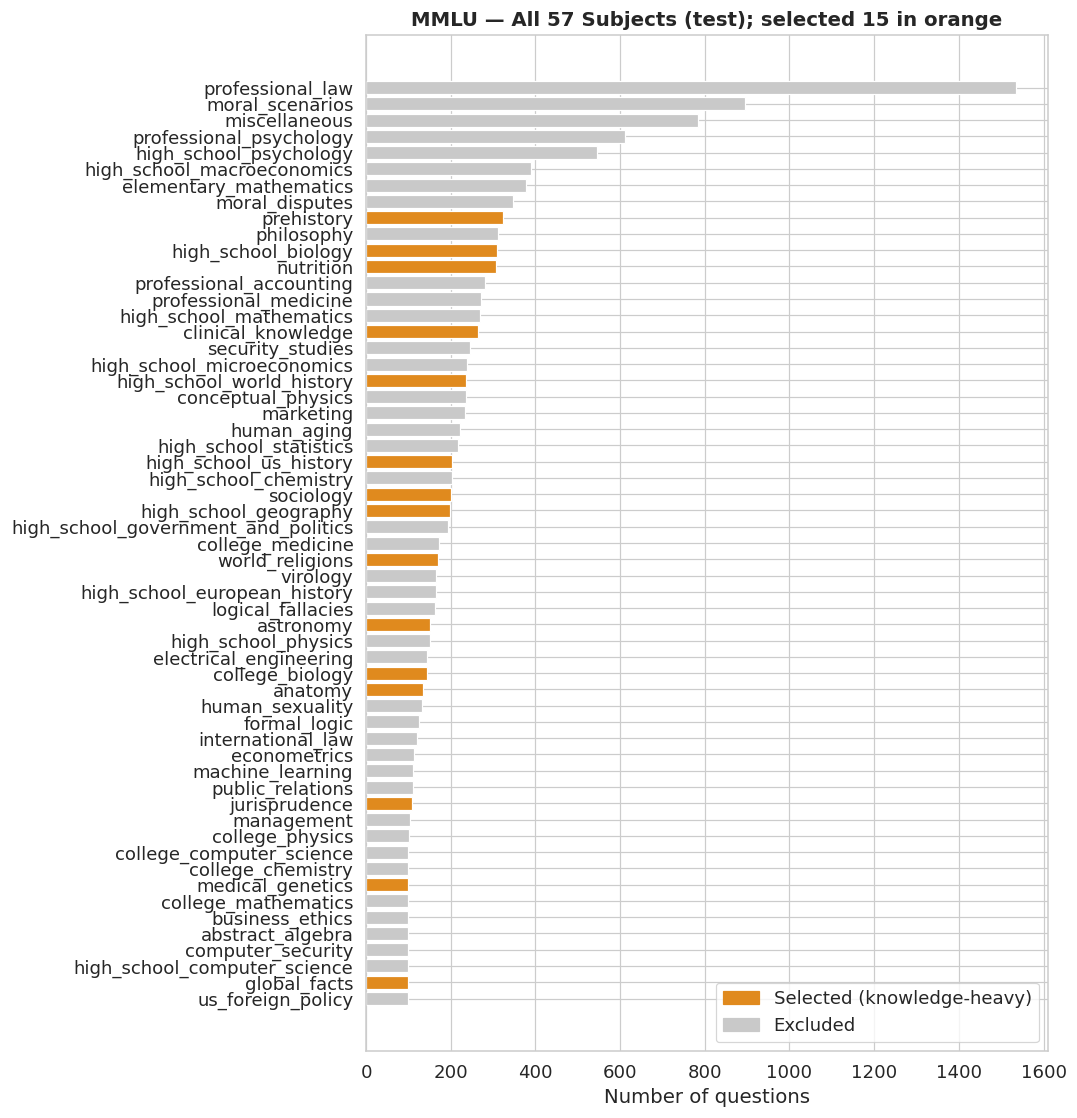

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_mmlu_all57_subjects.png


In [ ]:
selected = set(json.load(open(f'{PROJECT_ROOT}/data/mmlu/mmlu_manifest.json'))['subjects'])
counts = mmlu_df['subject'].value_counts().sort_values()
colors = [MMLU_C if s in selected else '#c9c9c9' for s in counts.index]

plt.figure(figsize=(8, 12))
plt.barh(counts.index, counts.values, color=colors)
plt.title('MMLU — All 57 Subjects (test); selected 15 in orange')
plt.xlabel('Number of questions'); plt.ylabel('')
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color=MMLU_C, label='Selected (knowledge-heavy)'),
                    Patch(color='#c9c9c9', label='Excluded')], loc='lower right')
save_fig('eda_mmlu_all57_subjects')

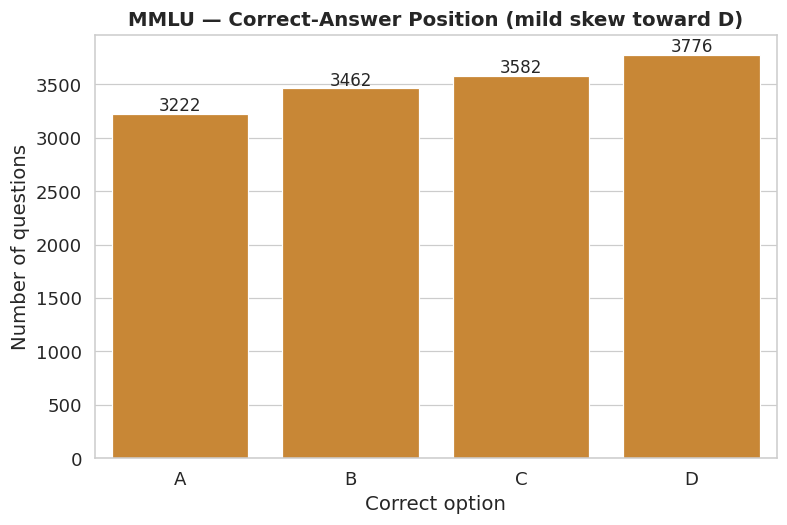

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_mmlu_answer_position.png


In [ ]:
pos = mmlu_df['answer'].value_counts().sort_index()
plt.figure()
sns.barplot(x=['A', 'B', 'C', 'D'], y=pos.values, color=MMLU_C)
for i, v in enumerate(pos.values):
    plt.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.title('MMLU — Correct-Answer Position (mild skew toward D)')
plt.xlabel('Correct option'); plt.ylabel('Number of questions')
save_fig('eda_mmlu_answer_position')

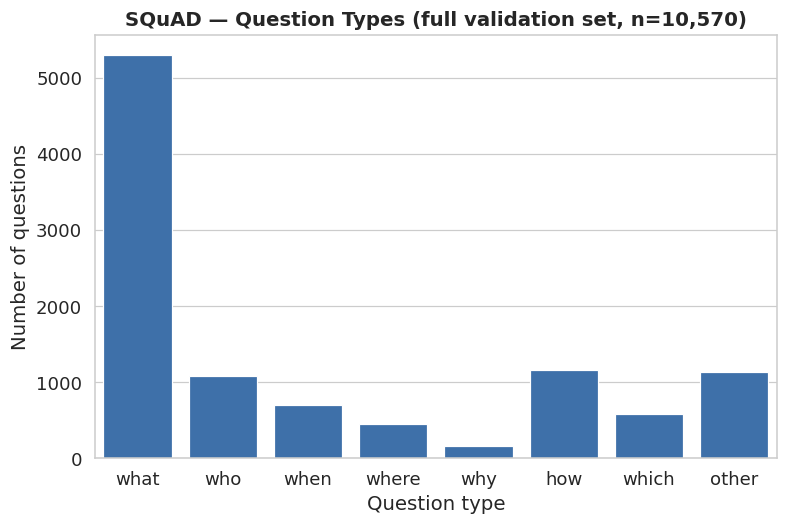

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_squad_full_question_types.png


In [ ]:
import re
TYPES = ['what', 'who', 'when', 'where', 'why', 'how', 'which', 'other']
def qtype(q):
    for w in re.findall(r'[a-z]+', q.lower())[:4]:
        if w in TYPES: return w
    return 'other'

sq_full_types = squad_df['question'].apply(qtype).value_counts().reindex(TYPES, fill_value=0)
plt.figure()
sns.barplot(x=sq_full_types.index, y=sq_full_types.values, color=SQUAD_C)
plt.title('SQuAD — Question Types (full validation set, n=10,570)')
plt.xlabel('Question type'); plt.ylabel('Number of questions')
save_fig('eda_squad_full_question_types')

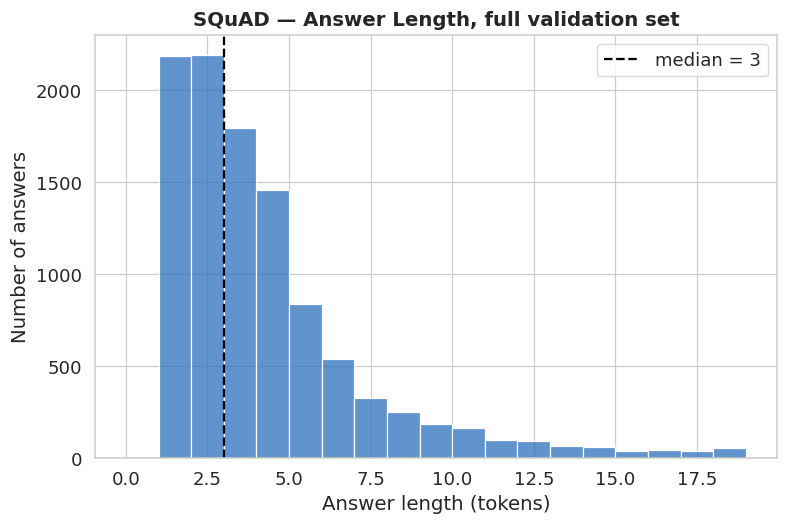

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_squad_full_answer_length.png


In [ ]:
sq_full_ans = squad_df['answers'].apply(lambda a: len(tok.encode(a['text'][0], add_special_tokens=False)))
plt.figure()
sns.histplot(sq_full_ans, bins=range(0, 20), color=SQUAD_C, edgecolor='white')
plt.axvline(sq_full_ans.median(), color='black', ls='--', lw=1.5,
            label=f'median = {int(sq_full_ans.median())}')
plt.title('SQuAD — Answer Length, full validation set')
plt.xlabel('Answer length (tokens)'); plt.ylabel('Number of answers')
plt.legend(); save_fig('eda_squad_full_answer_length')

In [ ]:
import re
TYPES = ['what', 'who', 'when', 'where', 'why', 'how', 'which', 'other']
def qtype(question):
    w = re.findall(r"[a-z]+", question.lower())
    for tok_ in w[:4]:                 # look at the first few words
        if tok_ in TYPES:
            return tok_
    return 'other'

sq_types = pd.Series([qtype(q['question']) for q in squad_eval]).value_counts().reindex(TYPES, fill_value=0)
mm_types = pd.Series([qtype(q['question']) for q in mmlu_eval]).value_counts().reindex(TYPES, fill_value=0)
print('SQuAD types:\n', sq_types, '\n\nMMLU types:\n', mm_types)


SQuAD types:
 what     244
who       46
when      36
where     27
why        9
how       59
which     25
other     54
Name: count, dtype: int64 

MMLU types:
 what      43
who        2
when       4
where      2
why        6
how       17
which    118
other    308
Name: count, dtype: int64


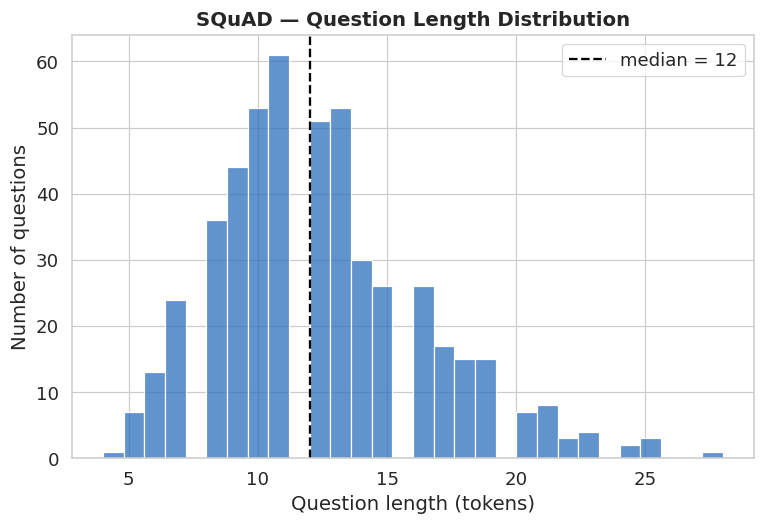

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_squad_question_length.png


In [ ]:
plt.figure()
sns.histplot(sq_q_len, bins=30, color=SQUAD_C, edgecolor='white')
plt.axvline(np.median(sq_q_len), color='black', ls='--', lw=1.5,
            label=f'median = {int(np.median(sq_q_len))}')
plt.title('SQuAD — Question Length Distribution')
plt.xlabel('Question length (tokens)'); plt.ylabel('Number of questions')
plt.legend(); save_fig('eda_squad_question_length')


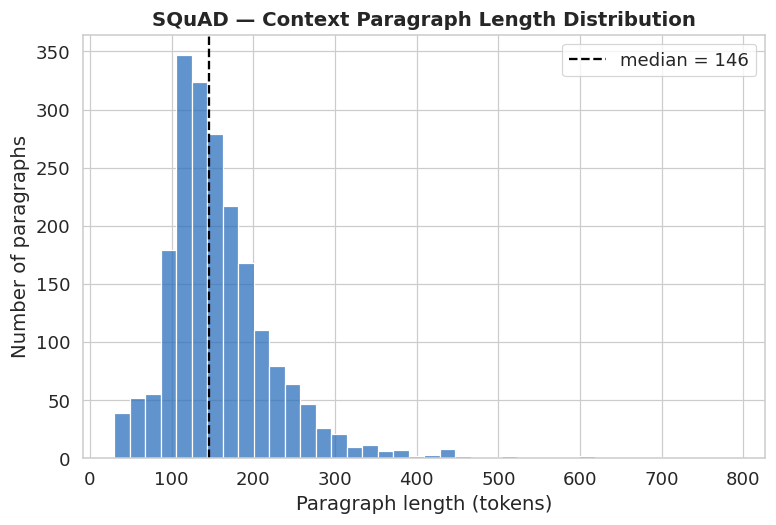

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_squad_context_length.png


In [ ]:
plt.figure()
sns.histplot(sq_ctx_len, bins=40, color=SQUAD_C, edgecolor='white')
plt.axvline(np.median(sq_ctx_len), color='black', ls='--', lw=1.5,
            label=f'median = {int(np.median(sq_ctx_len))}')
plt.title('SQuAD — Context Paragraph Length Distribution')
plt.xlabel('Paragraph length (tokens)'); plt.ylabel('Number of paragraphs')
plt.legend(); save_fig('eda_squad_context_length')


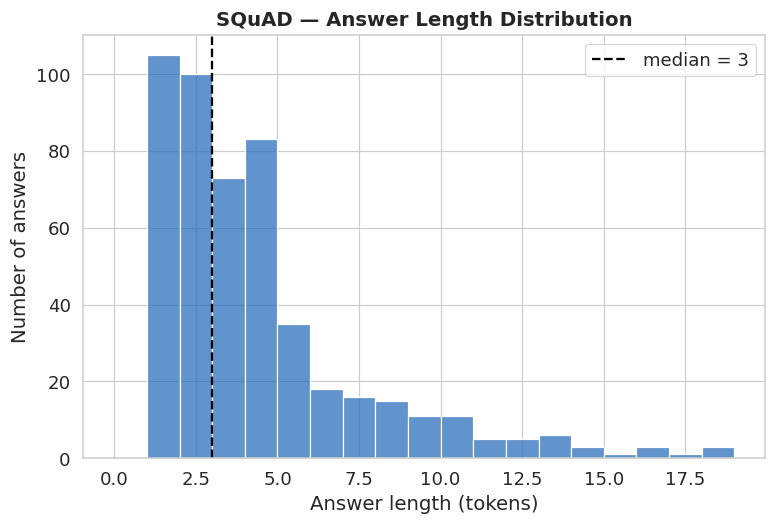

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_squad_answer_length.png


In [ ]:
plt.figure()
sns.histplot(sq_ans_len, bins=range(0, 20), color=SQUAD_C, edgecolor='white')
plt.axvline(np.median(sq_ans_len), color='black', ls='--', lw=1.5,
            label=f'median = {int(np.median(sq_ans_len))}')
plt.title('SQuAD — Answer Length Distribution')
plt.xlabel('Answer length (tokens)'); plt.ylabel('Number of answers')
plt.legend(); save_fig('eda_squad_answer_length')


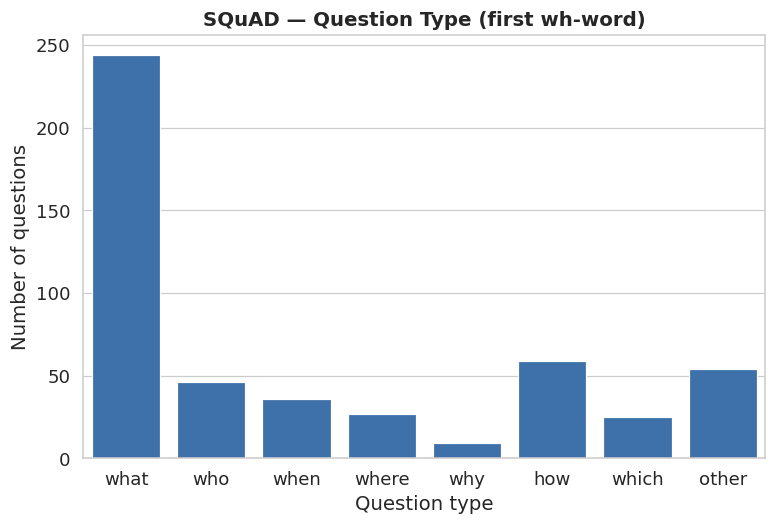

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_squad_question_types.png


In [ ]:
plt.figure()
sns.barplot(x=sq_types.index, y=sq_types.values, color=SQUAD_C)
plt.title('SQuAD — Question Type (first wh-word)')
plt.xlabel('Question type'); plt.ylabel('Number of questions')
save_fig('eda_squad_question_types')


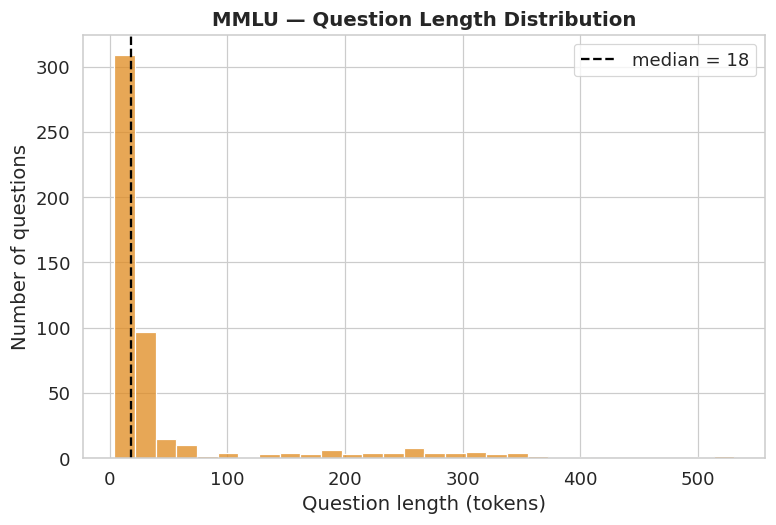

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_mmlu_question_length.png


In [ ]:
plt.figure()
sns.histplot(mm_q_len, bins=30, color=MMLU_C, edgecolor='white')
plt.axvline(np.median(mm_q_len), color='black', ls='--', lw=1.5,
            label=f'median = {int(np.median(mm_q_len))}')
plt.title('MMLU — Question Length Distribution')
plt.xlabel('Question length (tokens)'); plt.ylabel('Number of questions')
plt.legend(); save_fig('eda_mmlu_question_length')


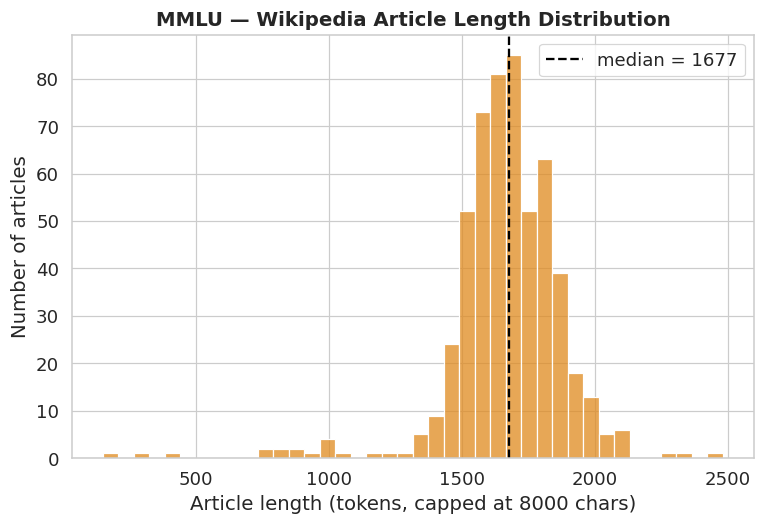

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_mmlu_article_length.png


In [ ]:
plt.figure()
sns.histplot(mm_art_len, bins=40, color=MMLU_C, edgecolor='white')
plt.axvline(np.median(mm_art_len), color='black', ls='--', lw=1.5,
            label=f'median = {int(np.median(mm_art_len))}')
plt.title('MMLU — Wikipedia Article Length Distribution')
plt.xlabel('Article length (tokens, capped at 8000 chars)'); plt.ylabel('Number of articles')
plt.legend(); save_fig('eda_mmlu_article_length')


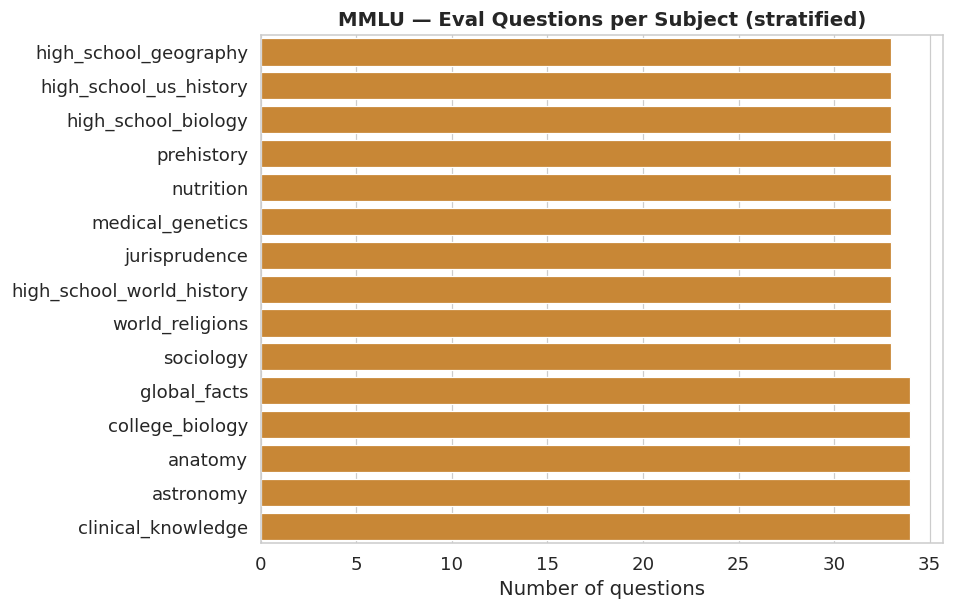

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_mmlu_subject_distribution.png


In [ ]:
subj = pd.Series([q['subject'] for q in mmlu_eval]).value_counts().sort_values()
plt.figure(figsize=(8, 6))
sns.barplot(x=subj.values, y=subj.index, color=MMLU_C)
plt.title('MMLU — Eval Questions per Subject (stratified)')
plt.xlabel('Number of questions'); plt.ylabel('')
save_fig('eda_mmlu_subject_distribution')


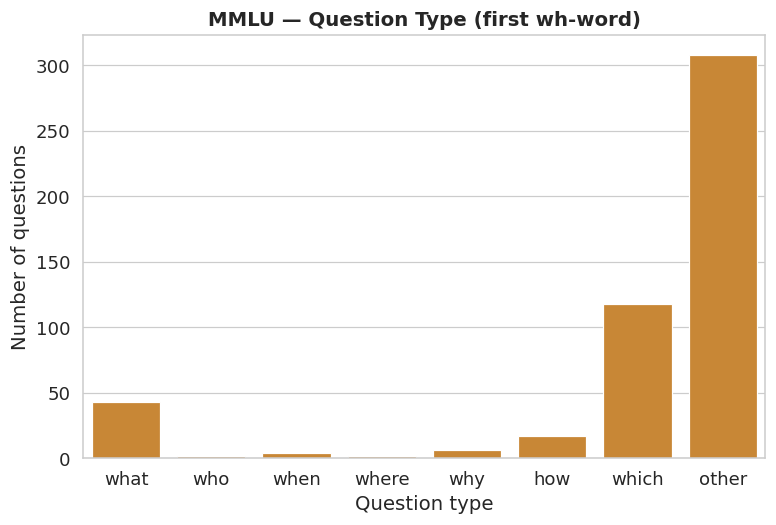

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_mmlu_question_types.png


In [ ]:
plt.figure()
sns.barplot(x=mm_types.index, y=mm_types.values, color=MMLU_C)
plt.title('MMLU — Question Type (first wh-word)')
plt.xlabel('Question type'); plt.ylabel('Number of questions')
save_fig('eda_mmlu_question_types')


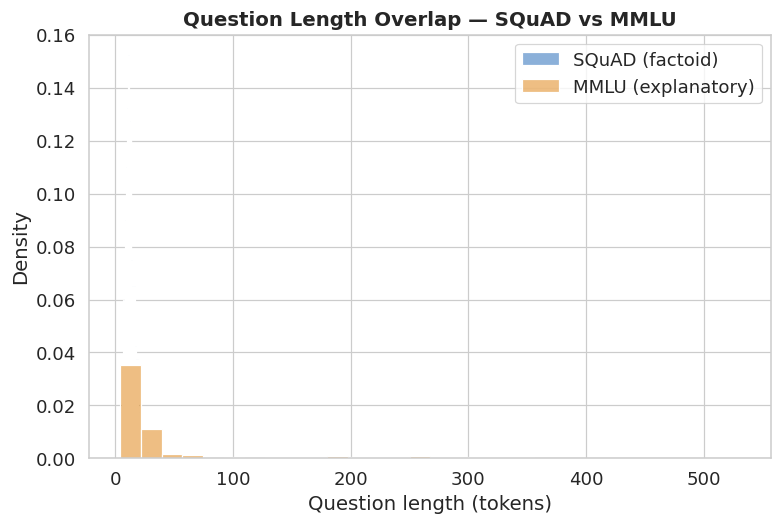

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_question_length_overlap.png


In [ ]:
plt.figure()
sns.histplot(sq_q_len, bins=30, color=SQUAD_C, label='SQuAD (factoid)', stat='density', alpha=0.55, edgecolor='white')
sns.histplot(mm_q_len, bins=30, color=MMLU_C, label='MMLU (explanatory)', stat='density', alpha=0.55, edgecolor='white')
plt.title('Question Length Overlap — SQuAD vs MMLU')
plt.xlabel('Question length (tokens)'); plt.ylabel('Density')
plt.legend(); save_fig('eda_question_length_overlap')


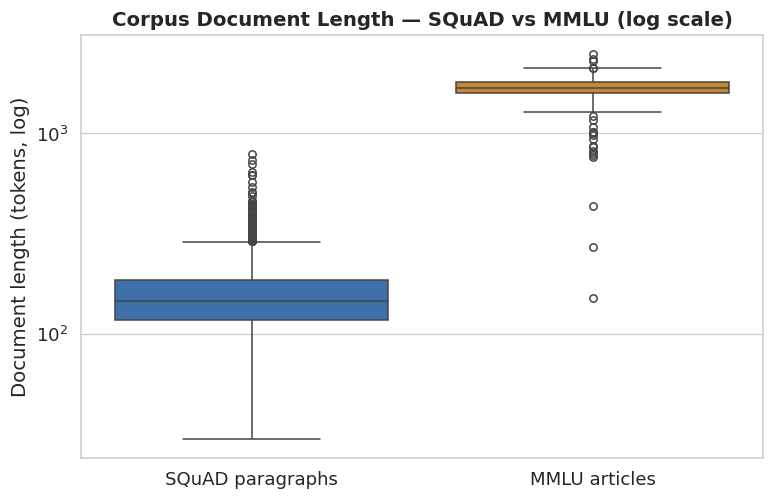

saved: /content/drive/MyDrive/thesis_rag/results/figures/eda_corpus_shape_comparison.png


In [ ]:
plt.figure()
df_len = pd.DataFrame({
    'tokens': np.concatenate([sq_ctx_len, mm_art_len]),
    'corpus': ['SQuAD paragraphs'] * len(sq_ctx_len) + ['MMLU articles'] * len(mm_art_len)})
sns.boxplot(data=df_len, x='corpus', y='tokens', hue='corpus',
            palette={'SQuAD paragraphs': SQUAD_C, 'MMLU articles': MMLU_C}, legend=False)
plt.yscale('log')
plt.title('Corpus Document Length — SQuAD vs MMLU (log scale)')
plt.xlabel(''); plt.ylabel('Document length (tokens, log)')
save_fig('eda_corpus_shape_comparison')


In [ ]:
def stats(name, arr):
    return {'variable': name, 'count': len(arr), 'mean': round(arr.mean(), 1),
            'median': int(np.median(arr)), 'std': round(arr.std(), 1),
            'min': int(arr.min()), 'max': int(arr.max())}

table = pd.DataFrame([
    stats('SQuAD question (tokens)', sq_q_len),
    stats('SQuAD context (tokens)', sq_ctx_len),
    stats('SQuAD answer (tokens)', sq_ans_len),
    stats('MMLU question (tokens)', mm_q_len),
    stats('MMLU article (tokens)', mm_art_len),
    stats('MMLU answer (tokens)', mm_ans_len),
])
table.to_csv(f'{PROJECT_ROOT}/results/figures/eda_descriptive_stats.csv', index=False)
print('saved eda_descriptive_stats.csv\n')
print(table.to_string(index=False))


saved eda_descriptive_stats.csv

               variable  count   mean  median   std  min  max
SQuAD question (tokens)    500   12.3      12   4.0    4   28
 SQuAD context (tokens)   2067  159.6     146  71.4   30  789
  SQuAD answer (tokens)    500    4.2       3   3.9    1   25
 MMLU question (tokens)    500   50.8      18  88.1    4  531
  MMLU article (tokens)    546 1667.8    1677 220.0  152 2482
   MMLU answer (tokens)    500    8.4       6   6.9    1   45
